In [40]:
import os
import os.path
os.chdir(os.path.dirname(__vsc_ipynb_file__))
!pwd

/Users/alan/GitHub/Work/colibri/weather-station


In [41]:
import glob
import re
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [42]:
datetimemin = datetime.fromisoformat("2025-08-15T00:00:00Z")
datetimemax = datetime.fromisoformat("2025-09-20T00:00:00Z")

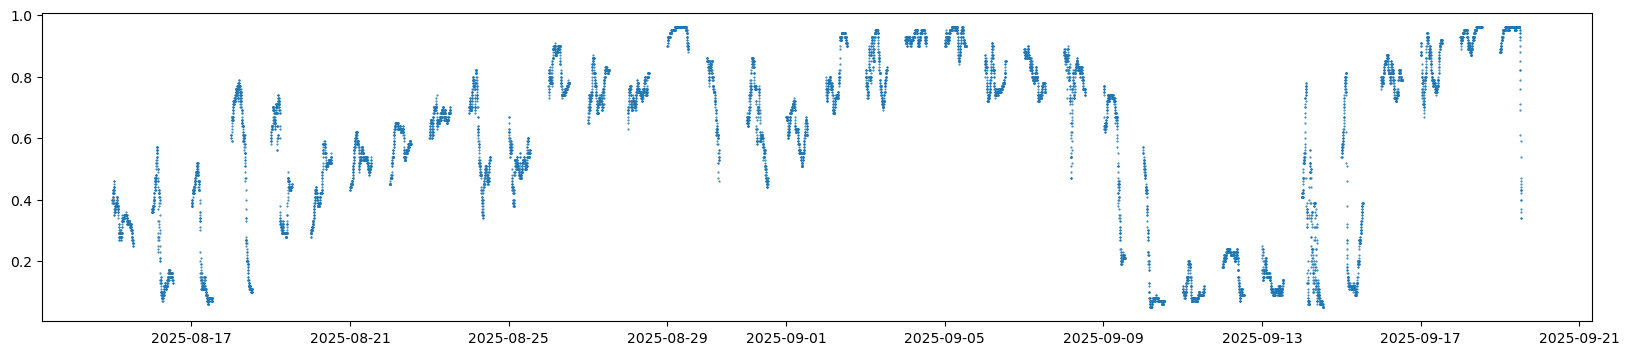

In [43]:
datere = re.compile(r"^.*Weather Station Information at ([-: 0-9]+Z)-+$")
humidityre = re.compile(r"^.* ([0-9]+),0% .*§F$")

bootes5datetimelist = []
bootes5humiditylist = []

for filename in sorted(glob.glob("bootes-5/*dome.txt")):
    with open(filename, "r", encoding="iso-8859-1") as file:
        text = file.read()
        lines = text.split("\n")
        for line in lines:
            if datere.match(line) is not None:
                date = datere.match(line).group(1)
                datetime = datetime.fromisoformat(date)
            elif humidityre.match(line) is not None:
                humidity = float(humidityre.match(line).group(1)) / 100
                if (
                    datetimemin <= datetime
                    and datetime <= datetimemax
                    and 0 <= humidity
                    and humidity <= 1.00
                ):
                    bootes5datetimelist.append(datetime)
                    bootes5humiditylist.append(humidity)


plt.figure(figsize=(20, 4))
plt.plot(bootes5datetimelist, bootes5humiditylist, ".", markersize=1)

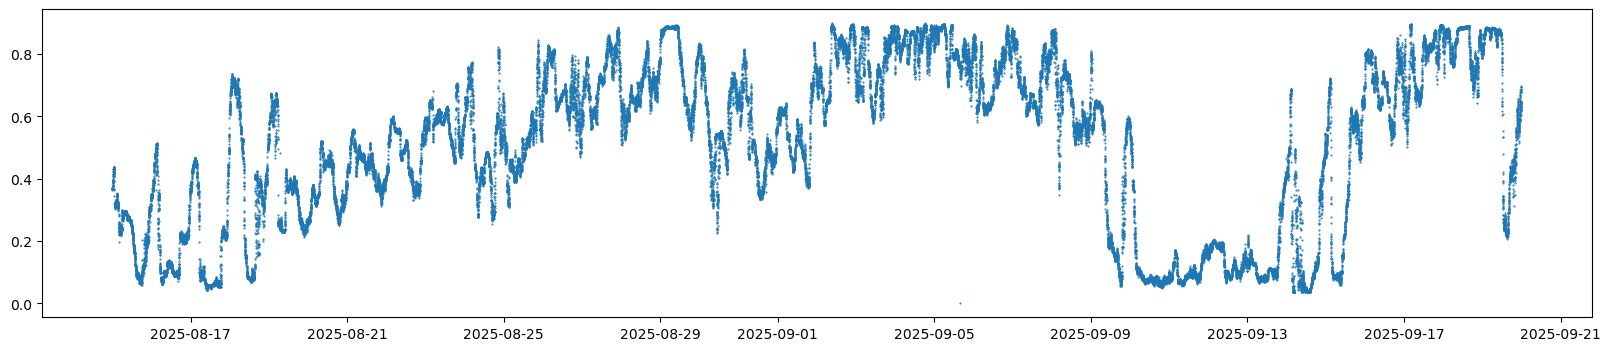

In [44]:
colibridatetimelist = []
colibrihumiditylist = []

for filename in sorted(glob.glob("colibri/*.txt")):
    with open(filename, "r") as file:
        text = file.read()
        lines = text.split("\n")
        for line in lines:
            fields = line.split()
            if len(fields) == 0:
                continue
            date = fields[1] + "T" + fields[2] + "Z"
            datetime = datetime.fromisoformat(date)
            humidity = float(fields[12]) / 100
            if  (
                    datetimemin <= datetime
                    and datetime <= datetimemax
                    and 0 <= humidity
                    and humidity <= 1.00
                ):
                colibridatetimelist.append(datetime)
                colibrihumiditylist.append(humidity)


plt.figure(figsize=(20, 4))
plt.plot(colibridatetimelist, colibrihumiditylist, ".", markersize=1)

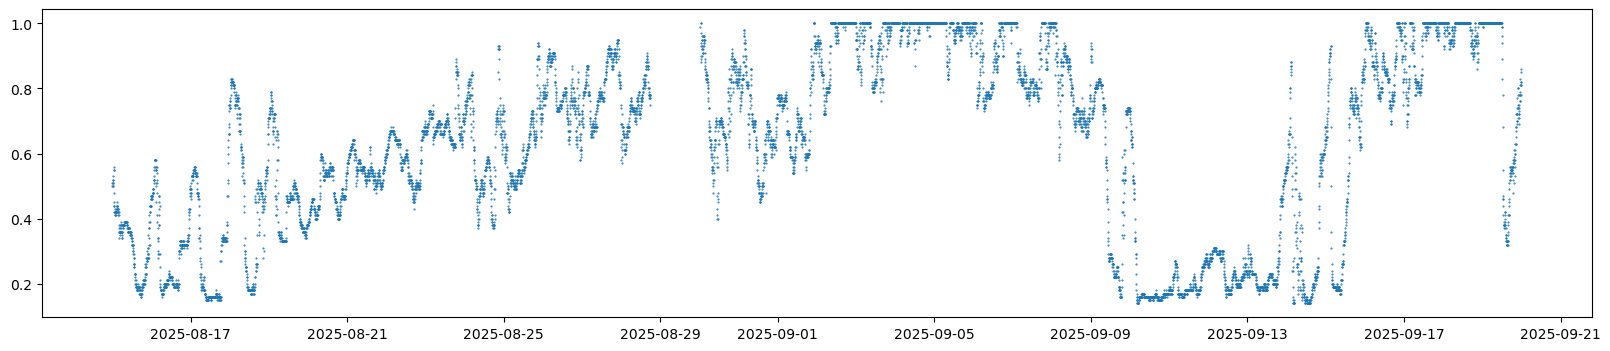

In [45]:
oanadatetimelist = []
oanahumiditylist = []

for filename in sorted(glob.glob("oan-a/*.txt")):
    with open(filename, "r") as file:
        text = file.read()
        lines = text.split("\n")
        for line in lines[2:]:
            fields = line.split()
            if len(fields) == 0:
                continue
            date = "%s-%s-%sT%sZ" % (fields[0][0:4], fields[0][4:6], fields[0][6:8], fields[1])
            datetime = datetime.fromisoformat(date)
            humidity = float(fields[5]) / 100
            if  (
                    datetimemin <= datetime
                    and datetime <= datetimemax
                    and 0 <= humidity
                    and humidity <= 1.00
                ):
                oanadatetimelist.append(datetime)
                oanahumiditylist.append(humidity)


plt.figure(figsize=(20, 4))
plt.plot(oanadatetimelist, oanahumiditylist, ".", markersize=1)

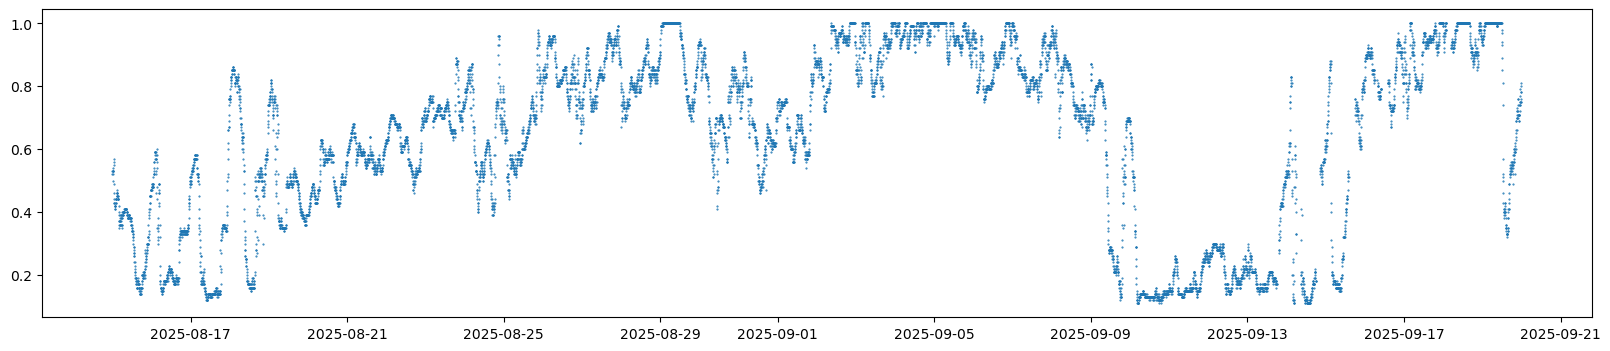

In [46]:
oanbdatetimelist = []
oanbhumiditylist = []

for filename in sorted(glob.glob("oan-b/*.txt")):
    with open(filename, "r") as file:
        text = file.read()
        lines = text.split("\n")
        for line in lines[2:]:
            fields = line.split()
            if len(fields) == 0:
                continue
            date = "%s-%s-%sT%sZ" % (fields[0][0:4], fields[0][4:6], fields[0][6:8], fields[1])
            datetime = datetime.fromisoformat(date)
            humidity = float(fields[5]) / 100
            if  (
                    datetimemin <= datetime
                    and datetime <= datetimemax
                    and 0 <= humidity
                    and humidity <= 1.00
                ):
                oanbdatetimelist.append(datetime)
                oanbhumiditylist.append(humidity)


plt.figure(figsize=(20, 4))
plt.plot(oanbdatetimelist, oanbhumiditylist, ".", markersize=1)

0.899
0.96
1.0
1.0


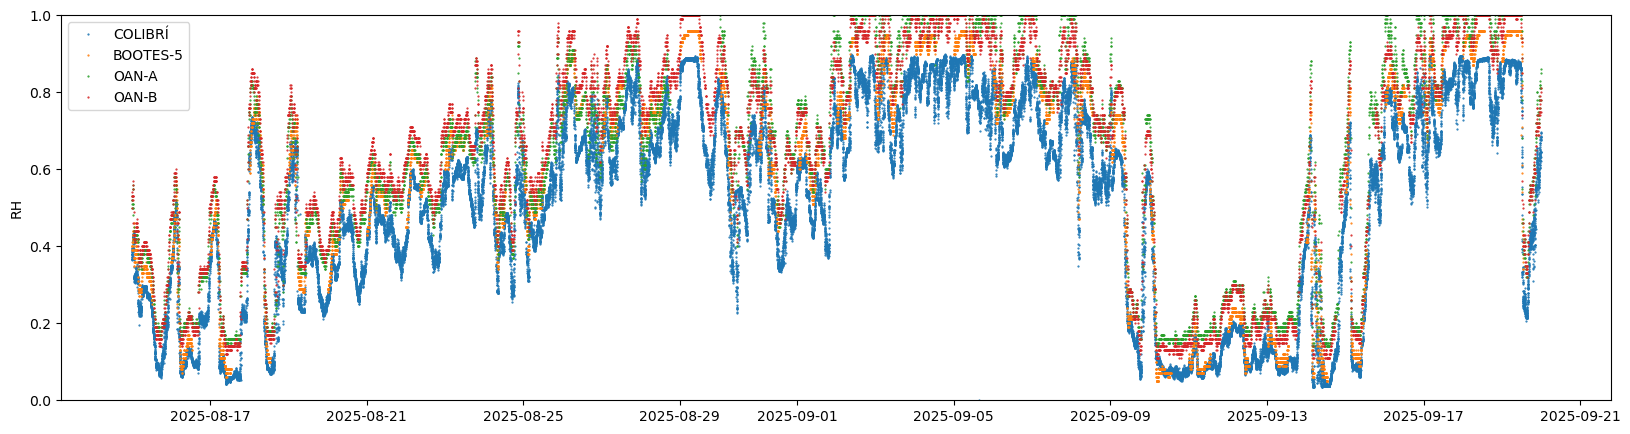

In [47]:
kwargs = {
    "markersize": 1.1
}


plt.figure(figsize=(20, 5))
plt.plot(colibridatetimelist, colibrihumiditylist, ".", label="COLIBRÍ", **kwargs)
print(max(*colibrihumiditylist))
plt.plot(bootes5datetimelist, bootes5humiditylist, ".", label="BOOTES-5", **kwargs)
print(max(*bootes5humiditylist))
plt.plot(oanadatetimelist, oanahumiditylist, ".", label="OAN-A", **kwargs)
print(max(*oanahumiditylist))
plt.plot(oanbdatetimelist, oanbhumiditylist, ".", label="OAN-B", **kwargs)
print(max(*oanbhumiditylist))
plt.legend()
plt.ylabel("RH")
plt.ylim(0,1)
plt.savefig("2025-09-30-humidity.png")

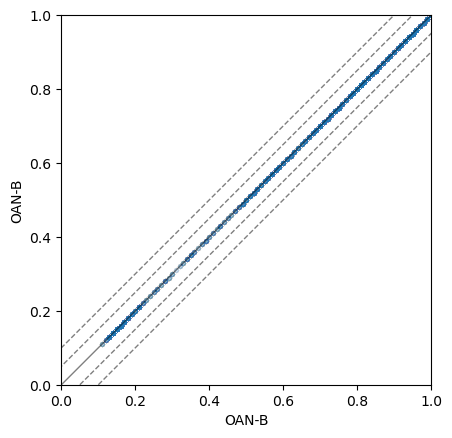

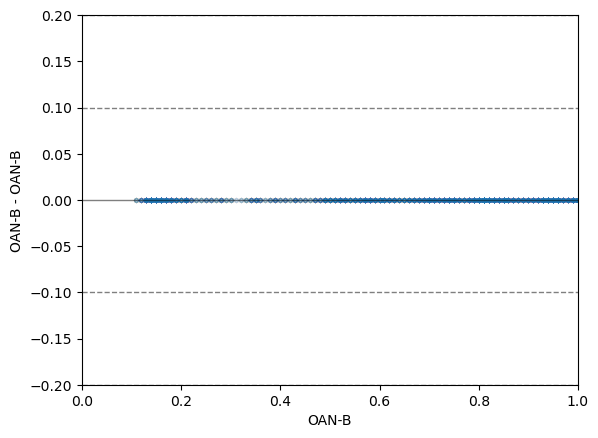

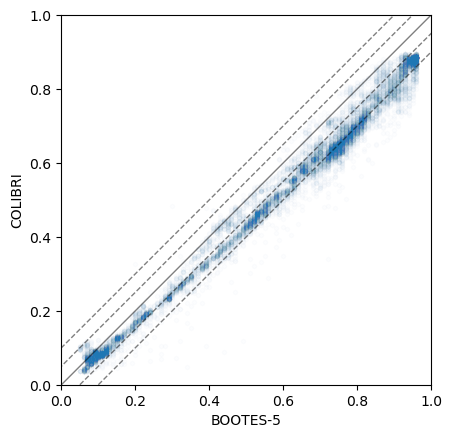

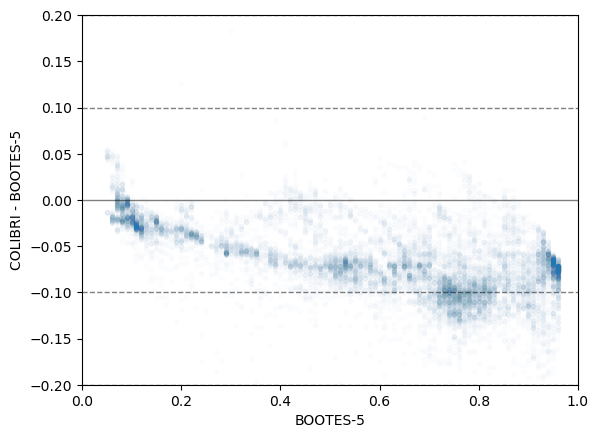

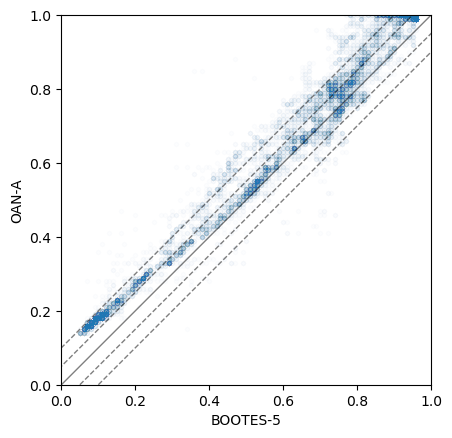

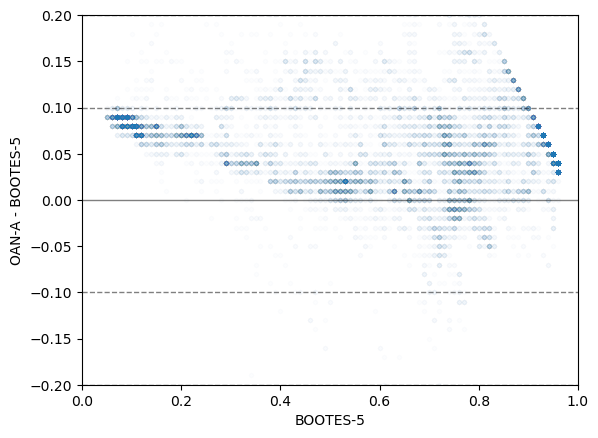

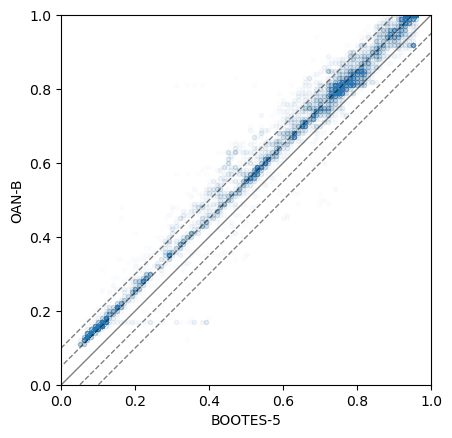

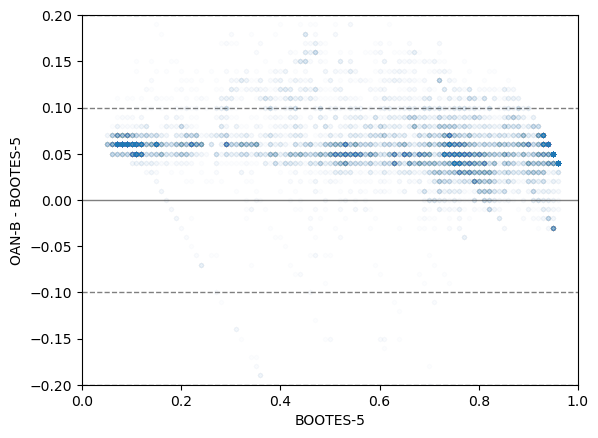

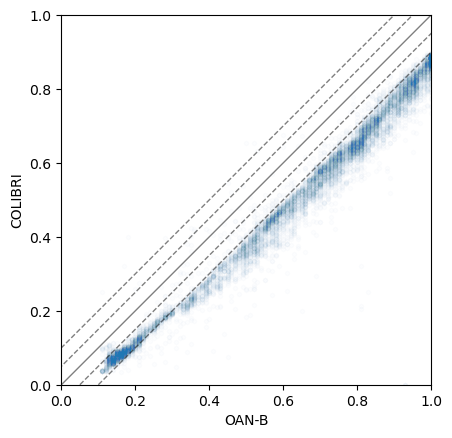

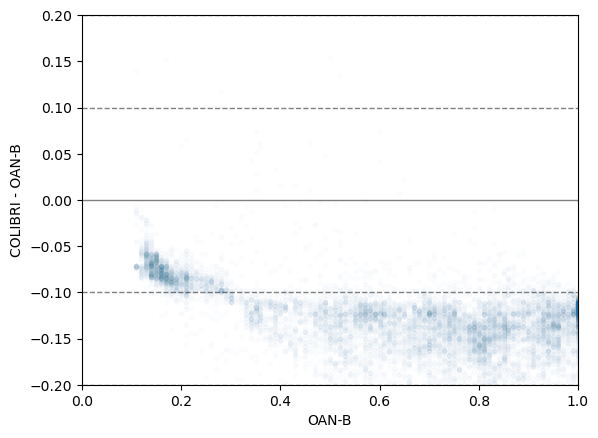

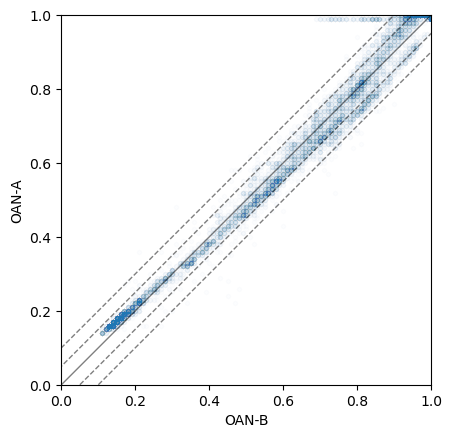

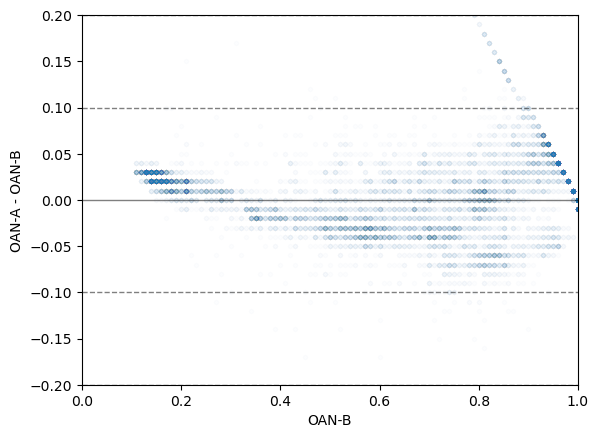

In [78]:
def correlation(adatetime, ahumidity, alabel, bdatetime, bhumidity, blabel):
    a = 0
    b = 0
    bdatetimematched = []
    bhumiditymatched = []
    for a in range(0, len(adatetime)):
        while b < len(bdatetime) - 1 and bdatetime[b] < adatetime[a]:
            b += 1
        bdatetimematched.append(bdatetime[b])
        bhumiditymatched.append(bhumidity[b])
    plt.plot(ahumidity, bhumiditymatched, ".", alpha=0.01)
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.xlabel(alabel)
    plt.ylabel(blabel)
    for d in [-0.10, -0.05, 0.00, +0.05, +0.10]:
        plt.plot([d,1+d],[0,1], "k" if d == 0 else "k--", linewidth=1, alpha=0.5)
    plt.gca().set_aspect('equal')
    plt.savefig("2025-09-30-correlation-%s-%s.png" % (alabel, blabel))
    plt.show()

    plt.plot(ahumidity, np.array(bhumiditymatched)-np.array(ahumidity), ".", alpha=0.01)
    plt.xlim(0,1)
    plt.ylim(-0.2,0.2)
    plt.xlabel(alabel)
    plt.ylabel("%s - %s" % (blabel, alabel))
    for d in [-0.2, -0.1, 0.00, +0.1, +0.2]:
        plt.plot([0,1],[d,d], "k" if d == 0 else "k--", linewidth=1, alpha=0.5)
    plt.savefig("2025-09-30-residual-%s-%s.png" % (alabel, blabel))
    plt.show()


correlation(oanbdatetimelist, oanbhumiditylist, "OAN-B", oanbdatetimelist, oanbhumiditylist, "OAN-B")
correlation(bootes5datetimelist, bootes5humiditylist, "BOOTES-5", colibridatetimelist, colibrihumiditylist, "COLIBRI")
correlation(bootes5datetimelist, bootes5humiditylist, "BOOTES-5", oanadatetimelist, oanahumiditylist, "OAN-A")
correlation(bootes5datetimelist, bootes5humiditylist, "BOOTES-5", oanbdatetimelist, oanbhumiditylist, "OAN-B")
correlation(oanbdatetimelist, oanbhumiditylist, "OAN-B", colibridatetimelist, colibrihumiditylist, "COLIBRI")
correlation(oanbdatetimelist, oanbhumiditylist, "OAN-B", oanadatetimelist, oanahumiditylist, "OAN-A")
        

